# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
train = pd.read_csv('iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
print(train.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')


C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_24328\1820989526.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=train, palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

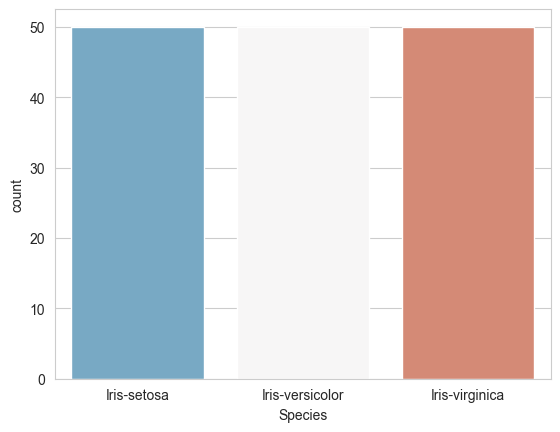

In [6]:
sns.set_style('whitegrid')
sns.countplot(x='Species', data=train, palette='RdBu_r')

C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_24328\2285317798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species',data=train,palette='rainbow')


<Axes: xlabel='Species', ylabel='count'>

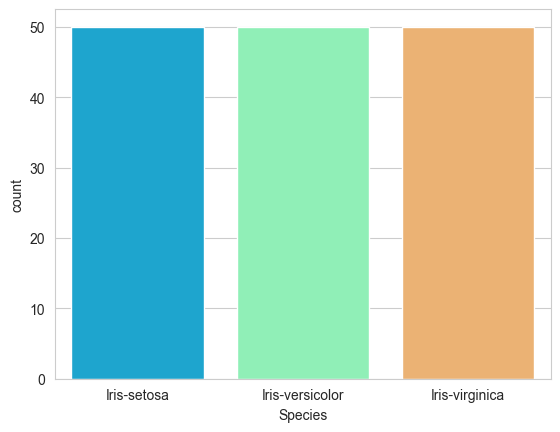

In [7]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.countplot(x='Species',data=train,palette='rainbow')

Text(0, 0.5, 'Count')

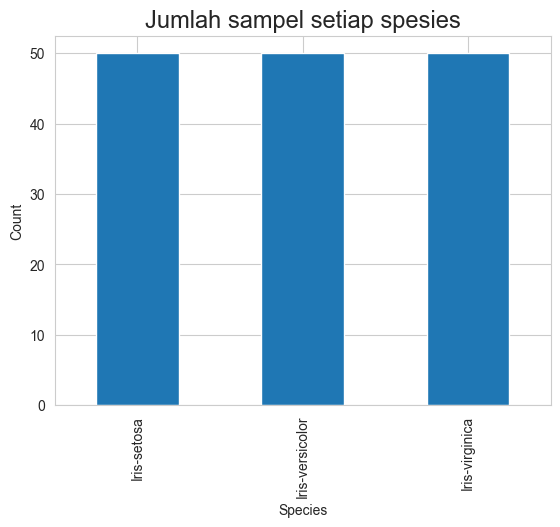

In [8]:
f_species_count = train.groupby('Species').size()
f_species_count.plot.bar()
plt.title("Jumlah sampel setiap spesies", fontsize=17)
plt.xlabel("Species")
plt.ylabel("Count")

C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_24328\585450928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species',data=train,palette='rainbow')


<Axes: xlabel='Species', ylabel='count'>

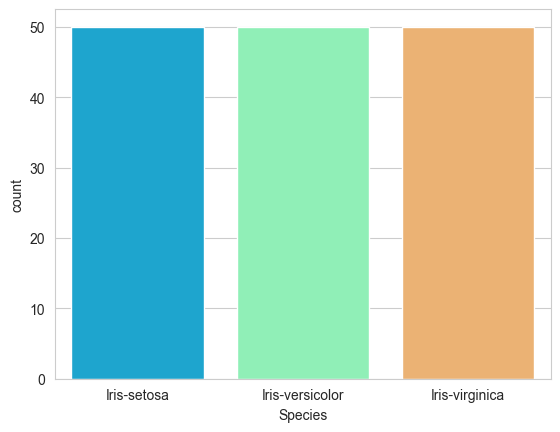

In [9]:
# Count of Species
sns.set_style('whitegrid')
sns.countplot(x='Species',data=train,palette='rainbow')

<Axes: title={'center': 'Histogram Sepal Length'}, xlabel='Sepal Length (cm)', ylabel='Count'>

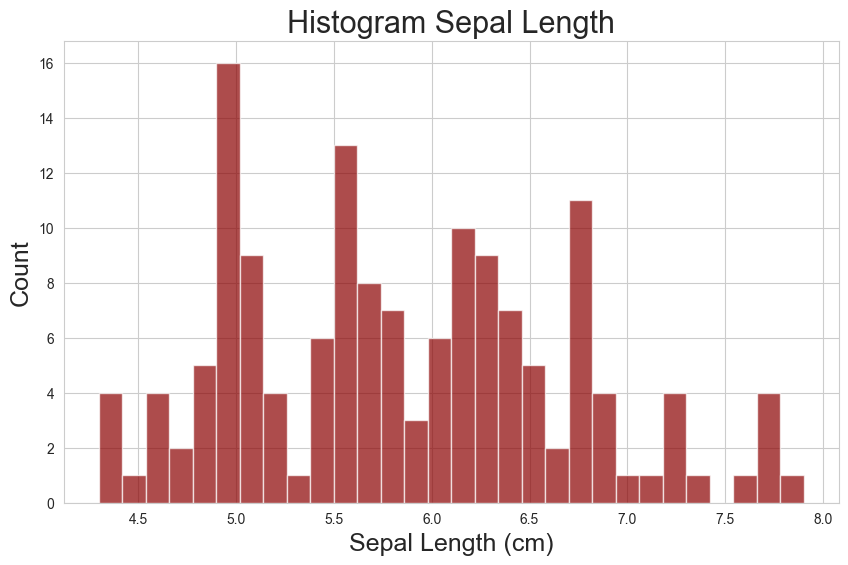

In [10]:
# Cek distribusi dari panjang sepal
plt.xlabel("Sepal Length (cm)", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram Sepal Length", fontsize=22)
train['SepalLengthCm'].hist(bins=30, color='darkred', alpha=0.7, figsize=(10,6))

C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_24328\4064855739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species',y='SepalLengthCm',data=train,palette='winter')


<Axes: xlabel='Species', ylabel='Sepal Length (cm)'>

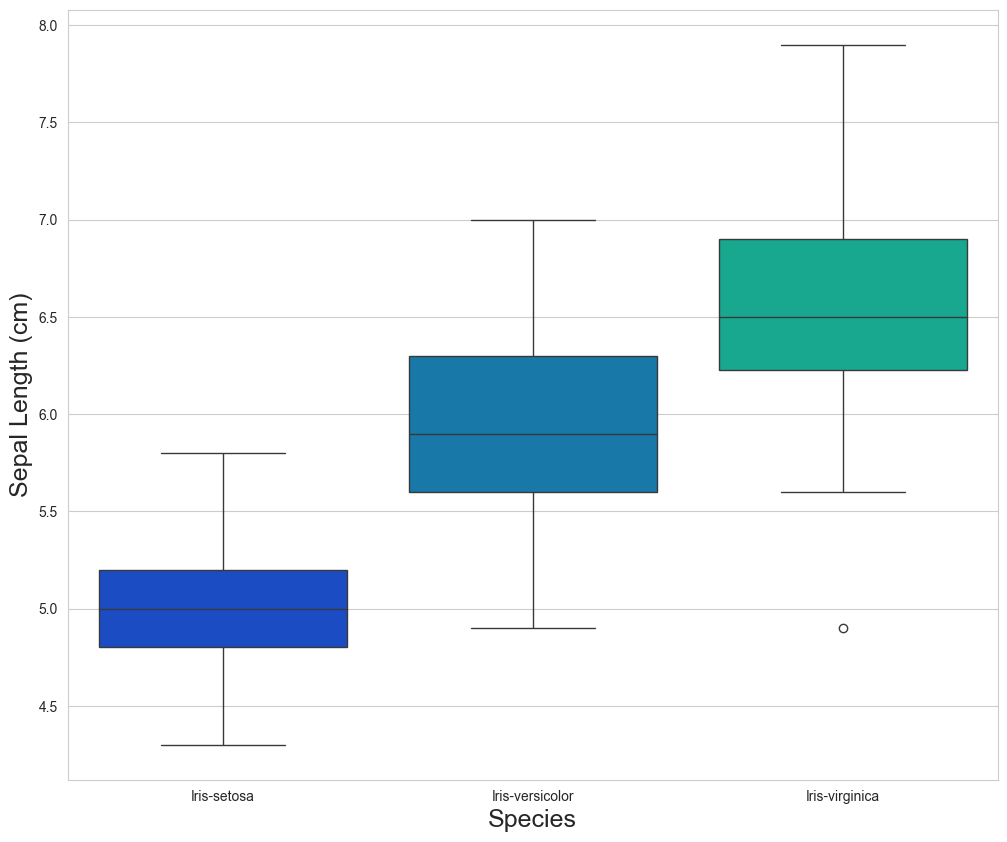

In [11]:
# Distribusi panjang sepal di setiap spesies
plt.figure(figsize=(12, 10))
plt.xlabel("Species",fontsize=18)
plt.ylabel("Sepal Length (cm)",fontsize=18)
sns.boxplot(x='Species',y='SepalLengthCm',data=train,palette='winter')

Text(0.5, 0, 'Species')

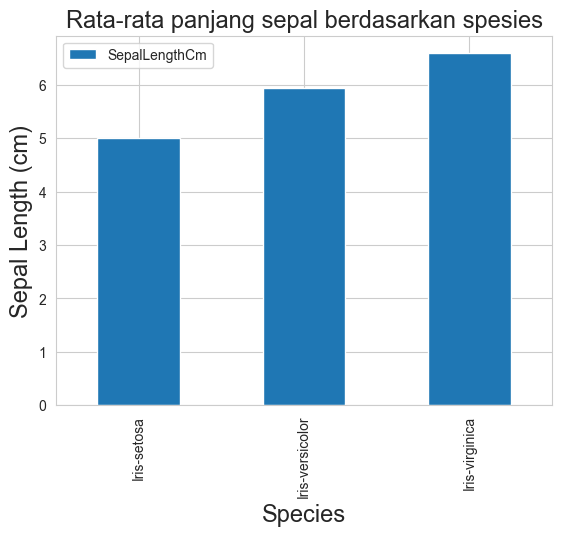

In [12]:
f_class_Age=train.groupby('Species')['SepalLengthCm'].mean()
f_class_Age = pd.DataFrame(f_class_Age)
f_class_Age.plot.bar(y='SepalLengthCm')
plt.title("Rata-rata panjang sepal berdasarkan spesies",fontsize=17)
plt.ylabel("Sepal Length (cm)", fontsize=17)
plt.xlabel("Species", fontsize=17)

### Fitur Engineering

In [13]:
a=list(f_class_Age['SepalLengthCm'])

def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return a[0]

        elif Pclass == 2:
            return a[1]

        else:
            return a[2]

    else:
        return Age

In [14]:
train['SepalLengthCm'].fillna(train['SepalLengthCm'].mean(), inplace=True)

C:\Users\MOH SYURIL ISWAN\AppData\Local\Temp\ipykernel_24328\2644344161.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train['SepalLengthCm'].fillna(train['SepalLengthCm'].mean(), inplace=True)


0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: SepalLengthCm, Length: 150, dtype: float64

Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

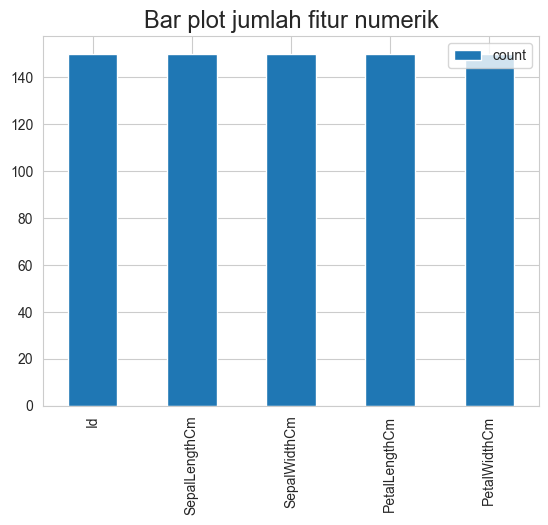

In [15]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [16]:
print(train.isnull().sum())
train.dropna(inplace=True)

train.head()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [17]:
# Drop semua kolom yang tidak penting (only if they exist)
columns_to_drop = ['PassengerId', 'Name', 'Ticket']
train.drop(columns=[col for col in columns_to_drop if col in train.columns], inplace=True)
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Species'] = le.fit_transform(train['Species'])
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


### Training

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Species',axis=1),
                                                    train['Species'], test_size=0.30,
                                                    random_state=42)

In [20]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (105, 5)
Test shape: (45, 5)


# **KNN**

In [21]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [22]:
y_pred = clf1.predict(X_test)

### Evaluation

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [24]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            1.000000   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            1.000000   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            1.000000   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            1.000000   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            1.000000   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            1.000000   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            1.000000   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            1.000000   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.990476   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.990476   
4   {'metric': 'euclidean', 'n_neighbors

In [27]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [28]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [29]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [30]:
import numpy as np

# Data penumpang baru (dalam urutan sama seperti fitur model)
# Ensure the new data has the same number of features as X_train
new_data = np.array([[5.1, 3.5, 1.4, 0.2, 0]])  # Example data with 5 features

# Prediksi apakah penumpang ini selamat atau tidak
prediction = best_model.predict(new_data)

print("Prediksi (0 = Tidak Selamat, 1 = Selamat):", prediction[0])

Prediksi (0 = Tidak Selamat, 1 = Selamat): 0


c:\Users\MOH SYURIL ISWAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
